# Embeddings
The concept of an embedding is to simply represent a complex concept/value into a lower dimensional representation.

We've technically already encounted a simplistic form of this concept when we worked with one-hot encodings:
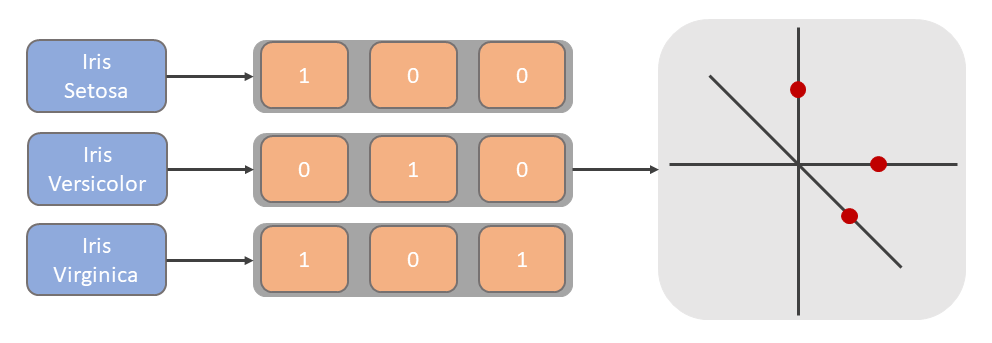

When working with one-hot encodings we are reducing the labels into binary vectors or embeddings:
$$iris_setosa = [1, 0, 0]$$

The benefits or unique property of a one-hot encoding is that it does not impart any bias/relationship between the different class vectors or embeddings:
$$dist_{setosa->versicolor} = dist_{[1, 0, 0]->[0, 1, 0]} = \sqrt{(0-1)^2 + (1-0)^2 + (0-0)^2} = \sqrt{2}$$
Which is the exact same distance for versicolor->virginica:
$$dist_{versicolor->virginica} = dist_{[0, 1, 0]->[0, 0, 1]} = \sqrt{(0-0)^2 + (0-1)^2 + (1-0)^2} = \sqrt{2}$$

This property is formed because one-hot encoding ensures that all vectors are perpindicular to each other. By adding a new dimension/column/feature for each additional label, we can ensure all of the one-hot encoded vectors are equidistant from each other.

If you think back to how our neural networks work, you'll see that this ensures that class labels do not interfere with each other:
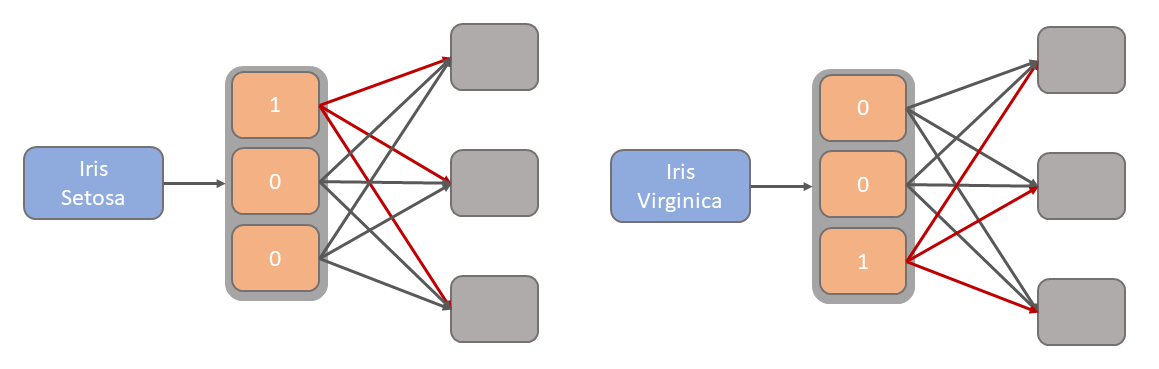

## Embeddings

However, we frequently run into situations where we want to capture the inter-relationships of our labels or simply want a lower dimensional representation of our labels (one-hot encoding creates another dimension for each additional class).

Example:
$$ one\_hot\_encoding = [1, 0, 0]$$
$$embedding = [0.8, 0.5, -0.3] $$

Embeddings accomplish this by representing the class as a vector of size N (where N is a hyperparameter). This has a couple of benefits:
 - Enables a smaller vector to represent a larger number of labels
 - Enables interplay between different labels
    - This is very important for tasks like NLP where the sequence of embeddings and their relationships to each other are critical to developing effective models
 - Enables us to create low-dimensional representations of high order concepts
    - Sometimes the embeddings, not the predictive power, are the outputs of a model



## NLP Embedding Example:

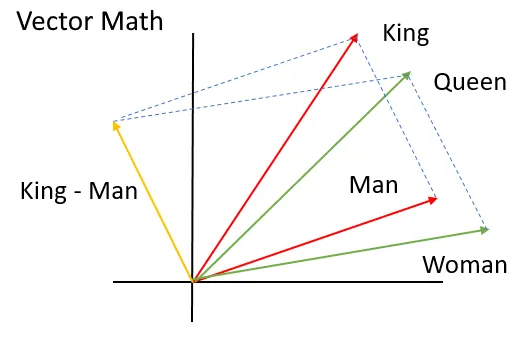

[source](https://medium.com/analytics-vidhya/word-embeddings-in-nlp-word2vec-glove-fasttext-24d4d4286a73)

In this example we see that the vectors to represent each of the words can be added/subtracted from each other and still remain internally consistent:
$$Woman + Royal = Queen = King - Man + Woman$$

## Embedding Layer in Keras

```python 

tf.keras.layers.Embedding(
    input_dim, # Size of the vocabulary (how many labels)
    output_dim, # The size of the vector/embedding to produce
    embeddings_initializer="uniform",
    embeddings_regularizer=None,
    activity_regularizer=None,
    embeddings_constraint=None,
    mask_zero=False,
    input_length=None, # The max lenght of a sequence (typically only for NLP tasks)
    sparse=False,
    **kwargs
)

```

A couple of notes:
 - Embedding layers are usually the first layer as they translate an input (label_encoded value) into an embedding that is used in the rest of the network
 - You need to know all the possible values/labels that the input can take on, otherwise you'll break the embedding layer
    - A way around this is to have a default label for unseen values, but this will greatly reduce the value of the embeddings if overused.
 - In many instance you'll only have one value to embed

## Class Exercise - Spotify Danceability

Using the provided spotif dataset, lets see if we can determine a song's danceability simply off of the information provided in the csv.



### Preprocessing

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
df = pd.read_csv('spotify_songs.csv')
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


This is our first model that will have multiple inputs:
 - embedding values
    - artist
    - genre
    - etc.
 - meta_data

For this we'll need to break out each of the different inputs.

In [3]:
meta_data_cols = ['track_popularity', 'energy', 'loudness', #'track_album_release_date'
             'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'tempo',
             'duration_ms', 'valence']

y = df['danceability']
artist = df['track_artist']
genre = df['playlist_genre']
sub_genre = df['playlist_subgenre']
meta_data = df[meta_data_cols]


### Scaling Input Data
We'll still need to standardize our numeric data, but the labeled data we'll need to label encode the data.

#### Label Encoding
Label encoding is simply a process of converting labels into unique numeric representaiton.

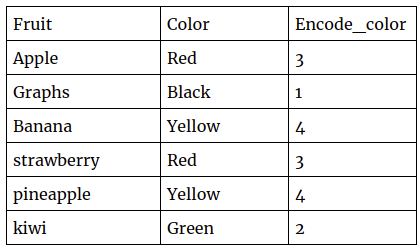

In [4]:
# Space for scaling (meta_data)
num_artists = len(set(artist))
num_genres = len(set(genre))
num_sub_genres = len(set(sub_genre))

artist_label_encoder = LabelEncoder()
genre_label_encoder = LabelEncoder()
sub_genre_label_encoder = LabelEncoder()

artist_labels = artist_label_encoder.fit_transform(artist)
genre_labels = genre_label_encoder.fit_transform(genre)
sub_genre_labels = sub_genre_label_encoder.fit_transform(sub_genre)

In [5]:
print(artist[0])
print(artist_labels[0])

Ed Sheeran
2782


In [6]:
# Space for label encoding (artist, genre, sub_genre)
scaler = StandardScaler()
normalized_data = scaler.fit_transform(meta_data)
normalize_meta_df = pd.DataFrame(normalized_data, columns=meta_data.columns)
normalize_meta_df.describe()

,track_popularity,energy,loudness,speechiness,acousticness,instrumentalness,liveness,tempo,duration_ms,valence
count,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04
mean,-1.406672e-16,4.031740e-16,1.449955e-17,-1.182687e-16,4.371505e-17,-7.871956e-17,1.231650e-16,1.688007e-17,1.776736e-16,1.579801e-16
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-1.700192e+00,-3.860786e+00,-1.329428e+01,-1.056809e+00,-7.983170e-01,-3.779530e-01,-1.232390e+00,-4.493185e+00,-3.706975e+00,-2.189910e+00
25%,-7.395656e-01,-6.501633e-01,-4.857132e-01,-6.521210e-01,-7.295647e-01,-3.779530e-01,-6.316705e-01,-7.776443e-01,-6.347793e-01,-7.701772e-01
50%,1.009826e-01,1.237138e-01,1.852164e-01,-4.399065e-01,-4.322454e-01,-3.778812e-01,-4.093978e-01,4.099393e-02,-1.637858e-01,6.172306e-03
75%,7.814264e-01,7.815093e-01,6.941860e-01,2.460892e-01,3.627309e-01,-3.564123e-01,3.747130e-01,4.845840e-01,4.643783e-01,7.825218e-01
max,2.302418e+00,1.665940e+00,2.675185e+00,8.004256e+00,3.727493e+00,4.055060e+00,5.221943e+00,4.406866e+00,4.880413e+00,2.060710e+00


### Identify embedding params
As we mentioned earlier, there are a couple of params we need to calculate when using embedding layers (max number of elements). Use the cell below to calculate those params.

In [7]:
# Space for work
import numpy as np
np.sqrt(num_artists)

103.40696301506973

### Define our Model

In [8]:
from keras import Model, Input
from keras.layers import Embedding, Concatenate, Dense, BatchNormalization, Dropout, Flatten
from keras.optimizers import Adam

In [9]:
# Hyperparameters
EMBED_ARTIST_SIZE = 8
EMBED_GENRE_SIZE = 8
EMBED_SUB_GENRE_SIZE = 8

In [14]:
def get_model():
    # Input Layers
    artist = Input(1)
    genre = Input(1)
    sub_genre = Input(1)
    meta = Input(normalize_meta_df.shape[1])
    
    # Embedding Layers
    artist_emb = Embedding(num_artists, EMBED_ARTIST_SIZE)(artist)
    genre_emb = Embedding(num_genres, EMBED_GENRE_SIZE)(genre)
    sub_genre_emb = Embedding(num_sub_genres, EMBED_SUB_GENRE_SIZE)(sub_genre)
    
    # Flatten Layers
    flat_artist = Flatten()(artist_emb)
    flat_genre = Flatten()(genre_emb)
    flat_sub_genre = Flatten()(sub_genre_emb)
    
    # Simplest way to merge multiple layers
    merged = Concatenate(axis=1)([
        flat_artist,
        flat_genre,
        flat_sub_genre,
        meta
    ])
    
    # Once we have a merged layer we've generated our "features" and can progress as normal
    dense_merge_1 = Dense(512, activation='relu')(merged)
    dense_merge_2 = Dense(256, activation='relu')(dense_merge_1)
    
    danceability = Dense(1, name='danceability')(dense_merge_2)
    
    model = Model(inputs=[artist, genre, sub_genre, meta], outputs=[danceability])
    # model = Model(inputs=[teams, team_seasons, coaches, game_meta], outputs=[score_diff])
    model.compile(
        loss={'danceability': 'mse'},
        optimizer='adam',
        metrics={'danceability': 'mae'}
    )
    
    return model

### Train and Test our Model
Let's run some training/testing of our model

In [15]:
# Space for work
model = get_model()
model.fit([artist_labels, genre_labels, sub_genre_labels, normalize_meta_df], y, batch_size=25, epochs=4)

Epoch 1/4
1314/1314 [==============================] - 10s 7ms/step - loss: 0.0940 - mae: 0.0940
Epoch 2/4
1314/1314 [==============================] - 9s 7ms/step - loss: 0.0708 - mae: 0.0708
Epoch 3/4
1314/1314 [==============================] - 9s 7ms/step - loss: 0.0620 - mae: 0.0620
Epoch 4/4
1314/1314 [==============================] - 9s 7ms/step - loss: 0.0560 - mae: 0.0560
